# DL050 循环网络与时间反向传播

本 Notebook 实际执行双序列完整数值链、独立梯度检查、全部 27 组固定协议训练与 13 幅原创图。先读 lecture.md，再用 lab.md 自测。只支持 float64 CPU 小规模输入域；不下载数据。已保存的输出来自全新实际 IPython 进程内核，未测试浏览器界面或 socket 传输。

In [1]:
import os, sys, json, tempfile, hashlib
from pathlib import Path
import numpy as np
import torch
os.environ['OMP_NUM_THREADS']='1'
os.environ['OPENBLAS_NUM_THREADS']='1'
torch.set_num_threads(1)
ROOT=Path.cwd()
if not (ROOT/'protocol.json').exists():
    raise RuntimeError('请将工作目录设为 units/050，再重新从第一格执行。')
sys.path.insert(0,str(ROOT))
from reference import fixture, full_bptt, finite_difference, NAMES
from experiment import hand_result, run_all, params_from_numpy, tensor, forward, token_loss, input_probe, DT, DEV
print({'python':sys.version.split()[0],'numpy':np.__version__,'torch':torch.__version__,'dtype':str(DT),'device':str(DEV),'threads':torch.get_num_threads()})
protocol=json.loads((ROOT/'protocol.json').read_text())
print('固定协议 SHA256:', hashlib.sha256((ROOT/'protocol.json').read_bytes()).hexdigest())
print('条件:',protocol['conditions'])

{'python': '3.12.14', 'numpy': '2.3.5', 'torch': '2.7.1+cpu', 'dtype': 'torch.float64', 'device': 'cpu', 'threads': 1}
固定协议 SHA256: ae7233cef0c890ee57bde1d5dfe8e0c4b5751f5c7e2af85d48bbacb8ff875c67
条件: [{'name': 'full', 'truncate': None, 'clip': None}, {'name': 'full_clip', 'truncate': None, 'clip': 0.25}, {'name': 'tbptt4_clip', 'truncate': 4, 'clip': 0.25}]


## 1 双序列前向
A 的长度是 3，B 的长度是 2；有效位置平均分母为 5。参数共享，状态独立。下表每行代表真实有效位置，完整精度保留在返回对象中。

In [2]:
hand=hand_result();ref=hand['reference']
print('位置       x          a          h          z          p         BCE')
for i,L in enumerate(hand['lengths']):
    for t in range(L):
        vals=[hand['x'][i][t][0],ref['a'][i][t][0],ref['h'][i][t+1][0],ref['z'][i][t],ref['prob'][i][t],ref['terms'][i][t]]
        print(f'{"AB"[i]}{t+1}   '+''.join(f'{v:11.6f}' for v in vals))
print('平均损失:',ref['loss'],'Python math 标量损失:',hand['scalar_loss'])

位置       x          a          h          z          p         BCE
A1      1.000000   0.500000   0.462117   0.123482   0.530831   0.633311
A2      0.000000   0.377270   0.360335   0.052234   0.513056   0.719605
A3     -1.000000  -0.083799  -0.083604  -0.258523   0.435727   0.830740
B1     -1.000000  -0.300000  -0.291313  -0.403919   0.400371   0.511444
B2      0.500000   0.125212   0.124562  -0.112806   0.471828   0.751140
平均损失: 0.6892480878759789 Python math 标量损失: 0.689248087875979


## 2 完整 BPTT 与共享参数
先加当前输出路径和未来时间路径，再乘 tanh 导数。每个位置贡献累加到同一参数；下表的 e 已经包含 1/5。

In [3]:
print('位置    e          直接项       未来项       总状态梯度      delta')
for i,L in enumerate(hand['lengths']):
    for t in range(L):
        vals=[ref['dz'][i][t]]+[ref[k][i][t][0] for k in ['direct','future','dh','delta']]
        print(f'{"AB"[i]}{t+1} '+''.join(f'{v:13.8f}' for v in vals))
print('各位置对共享参数的贡献')
for k in NAMES:
    print(k, np.array(ref['contributions'][k]).reshape(2,3), '总和',ref['grads'][k])

位置    e          直接项       未来项       总状态梯度      delta
A1   -0.09383373  -0.06568361   0.01292716  -0.05275646  -0.04149020
A2    0.10261111   0.07182778  -0.04706764   0.02476014   0.02154526
A3   -0.11285461  -0.07899823   0.00000000  -0.07899823  -0.07844607
B1    0.08007423   0.05605196  -0.04367805   0.01237391   0.01132383
B2   -0.10563435  -0.07394405   0.00000000  -0.07394405  -0.07279675
各位置对共享参数的贡献
U [[-0.0414902   0.          0.07844607]
 [-0.01132383 -0.03639838  0.        ]] 总和 [[-0.01076632989279111]]
W [[-0.          0.00995643 -0.02826683]
 [ 0.          0.02120661  0.        ]] 总和 [[0.0028962194142202052]]
b [[-0.0414902   0.02154526 -0.07844607]
 [ 0.01132383 -0.07279675  0.        ]] 总和 [-0.15986392742776578]
v [[-0.04336218  0.03697433  0.00943506]
 [-0.02332663 -0.01315804  0.        ]] 总和 [-0.03343746452308858]
c [[-0.09383373  0.10261111 -0.11285461]
 [ 0.08007423 -0.10563435  0.        ]] 总和 -0.12963735086623257


## 3 同步更新和新的下一次前向
所有新参数来自同一个旧参数向量与总梯度。h0 重新置零。总损失下降不要求每个位置都改善。

In [4]:
print('参数 | 旧值 | 总梯度 | 新值')
for k in NAMES:
    print(k,np.array(hand['initial_parameters'][k]).item(),np.array(ref['grads'][k]).item(),np.array(hand['updated_parameters'][k]).item())
print('新前向 p:',hand['next_forward']['prob'])
print('旧、新平均损失:',ref['loss'],hand['next_forward']['loss'])
p,x,l,y=fixture()
for eps in [1e-4,1e-5,1e-6]:
    fd=finite_difference(p,x,l,y,eps)
    print('有限差分 epsilon, max abs error:',eps,max(np.max(np.abs(fd[k]-np.array(ref['grads'][k]))) for k in NAMES))

参数 | 旧值 | 总梯度 | 新值
U 0.4 -0.01076632989279111 0.40215326597855827
W 0.6 0.0028962194142202052 0.599420756117156
b 0.1 -0.15986392742776578 0.13197278548555316
v 0.7 -0.03343746452308858 0.7066874929046176
c -0.2 -0.12963735086623257 -0.1740725298267535
新前向 p: [[0.5426869888464984, 0.5272952449413566, 0.45136766586010846], [0.4108405740959512, 0.4870779399138393, 0.4870779399138393]]
旧、新平均损失: 0.6892480878759789 0.6808738980987059
有限差分 epsilon, max abs error: 0.0001 1.955362538552663e-09
有限差分 epsilon, max abs error: 1e-05 2.0798918143327683e-11
有限差分 epsilon, max abs error: 1e-06 5.410560888208238e-11


## 4 运行独立数值与行为检查
包括矩阵情况、每参数与每输入差分、共享 W 的解绑定、mask/reset、detach、真实训练一步及输入域拒绝。正常与 -O 另外在命令行执行；这里在新内核调用相同公开检查入口。

In [5]:
from test_experiment import main as run_checks
run_checks()

{
  "status": "author checks completed",
  "optimized_python": false,
  "checks": [
    "independent math-scalar forward and BCE",
    "scalar and matrix NumPy BPTT vs autograd and central finite differences at three epsilons; every parameter and input",
    "shared recurrent weight equals sum of independently untied temporal copies",
    "torch.nn.RNN official cell mapping with explicit dtype/device and merged bias",
    "state freeze and loss mask make padding inert",
    "batch vs independent sequences and batch permutation invariance",
    "detach identical forward values; zero early gradient across fixed block boundary",
    "production SGD entry vs independent NumPy terminal loss, clipping, synchronous update and next forward",
    "explicit input bounds and invalid dtype/length/truncation/rate checks active under -O",
    "data regeneration, balance, distinct rows across splits and array hashes"
  ]
}


## 5 真实运行全部固定协议
27 组全部训练，固定 320 步终点。新结果写临时目录，不覆盖随课程提供的原始科学结果。与原始记录比较所有历史与最终数值，wall time 不参与等值判断。这里会花费数十秒到数分钟。

In [6]:
reproduction_dir=Path(tempfile.mkdtemp(prefix='dl050-notebook-'))
reproduction=run_all(reproduction_dir)
archived=json.loads((ROOT/'outputs/results.json').read_text())
if reproduction!=archived:
    raise RuntimeError('当前重现与存档不同，请比较版本、协议、数据与逐步数值，不要静默覆盖。')
print('全部 27 组的逐步历史、指标和敏感度与原始记录逐值一致。')

d2_s7_full complete {'bce': 0.0014778506054743405, 'accuracy': 1.0}


d2_s7_full_clip complete {'bce': 0.0015279738657564795, 'accuracy': 1.0}


d2_s7_tbptt4_clip complete {'bce': 0.0015279738657564795, 'accuracy': 1.0}


d2_s19_full complete {'bce': 0.001214579554289977, 'accuracy': 1.0}


d2_s19_full_clip complete {'bce': 0.0012511224047075534, 'accuracy': 1.0}


...

d24_s19_tbptt4_clip complete {'bce': 0.0017339591156249848, 'accuracy': 1.0}


d24_s41_full complete {'bce': 0.7000240796578454, 'accuracy': 0.52734375}


d24_s41_full_clip complete {'bce': 0.05704966133962093, 'accuracy': 0.984375}


d24_s41_tbptt4_clip complete {'bce': 0.014495852591000044, 'accuracy': 1.0}


全部 27 组的逐步历史、指标和敏感度与原始记录逐值一致。


## 6 全部 seed 汇总与负面结果
每个值来自真实训练，准确率为 1 仅表示这份测试样本上的结果。SD 是 3 个 seed 的描述性变动，不是总体置信区间。

In [7]:
for delay in protocol['delays']:
    for condition in protocol['conditions']:
        rr=[r for r in reproduction['runs'] if r['delay']==delay and r['condition']==condition['name']]
        acc=np.array([r['final']['test']['accuracy'] for r in rr],dtype=np.float64)
        bce=np.array([r['final']['test']['bce'] for r in rr],dtype=np.float64)
        print(delay,condition['name'],'acc seeds',acc.tolist(),'mean',float(acc.mean()),'sample SD',float(acc.std(ddof=1)),'BCE seeds',bce.tolist())
print('长延迟的截断组可成功，并不说明它具有完整长路径梯度；状态数值仍然跨边界传递。')

2 full acc seeds [1.0, 1.0, 1.0] mean 1.0 sample SD 0.0 BCE seeds [0.0014778506054743405, 0.001214579554289977, 0.0012481419647554144]
2 full_clip acc seeds [1.0, 1.0, 1.0] mean 1.0 sample SD 0.0 BCE seeds [0.0015279738657564795, 0.0012511224047075534, 0.001272233697641799]
2 tbptt4_clip acc seeds [1.0, 1.0, 1.0] mean 1.0 sample SD 0.0 BCE seeds [0.0015279738657564795, 0.0012511224047075534, 0.001272233697641799]
8 full acc seeds [1.0, 1.0, 1.0] mean 1.0 sample SD 0.0 BCE seeds [0.001324956968165723, 0.0011344159848863122, 0.001243026621388278]
8 full_clip acc seeds [1.0, 1.0, 1.0] mean 1.0 sample SD 0.0 BCE seeds [0.0013402939071722182, 0.0011606650532938437, 0.0012598482103843575]
8 tbptt4_clip acc seeds [1.0, 1.0, 1.0] mean 1.0 sample SD 0.0 BCE seeds [0.008397872656543189, 0.003582272621615518, 0.0009116105303172346]
24 full acc seeds [0.48046875, 0.53125, 0.52734375] mean 0.5130208333333334 sample SD 0.028258508351836853 BCE seeds [0.6945066551714163, 0.6930821932116138, 0.7000240

## 7 状态值相同而梯度不同
使用 delay=24 的同一个参数和同一输入。固定 K=4 的末块只有第 25 步，所以训练图对前 24 步输入的梯度为零。

In [8]:
from experiment import init_params
from generate_data import make_split
xx,yy=make_split(8,24,5101);p=init_params(7)
lengths=torch.full((8,),25,dtype=torch.int64,device=DEV)
z_full,_=forward(p,tensor(xx),lengths)
z_trunc,_=forward(p,tensor(xx),lengths,4)
print('两图前向最大差:',float((z_full-z_trunc).abs().max().detach()))
gfull=input_probe(p,tensor(xx));gtrunc=input_probe(p,tensor(xx),4)
print('完整图各时刻敏感度:',gfull)
print('截断图各时刻敏感度:',gtrunc)
if max(gtrunc[:24])!=0.0: raise RuntimeError('截断边界行为异常')

两图前向最大差: 0.0
完整图各时刻敏感度: [0.019867733967349963, 0.07064238940643273, 0.12957768104000514, 0.1949648913144827, 0.1558929320975019, 0.08184241209564284, 0.2682682397365133, 0.1715179328886759, 0.3198189815441802, 0.13138138540406313, 0.30990451322137186, 0.17194430754482407, 0.27530244591860326, 0.20324879070847113, 0.2922612806193627, 0.3829008341400955, 0.21866830055186914, 0.2329781217823656, 0.3184440325681861, 0.5505014871787106, 0.6380351183508988, 0.2927129884142398, 0.2936015930190604, 0.4638541906638567, 0.28691441177453253]
截断图各时刻敏感度: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.28691441177453253]


## 8 重建并嵌入真实 PNG
所有图例位于数据轴外的空白带。图 6 是机制示意；图 13 是明确标记的事后反事实诊断。每张图以 PNG bytes 内嵌到 Notebook，不依赖外部图片显示路径。

13 figures generated
01_unrolled.png


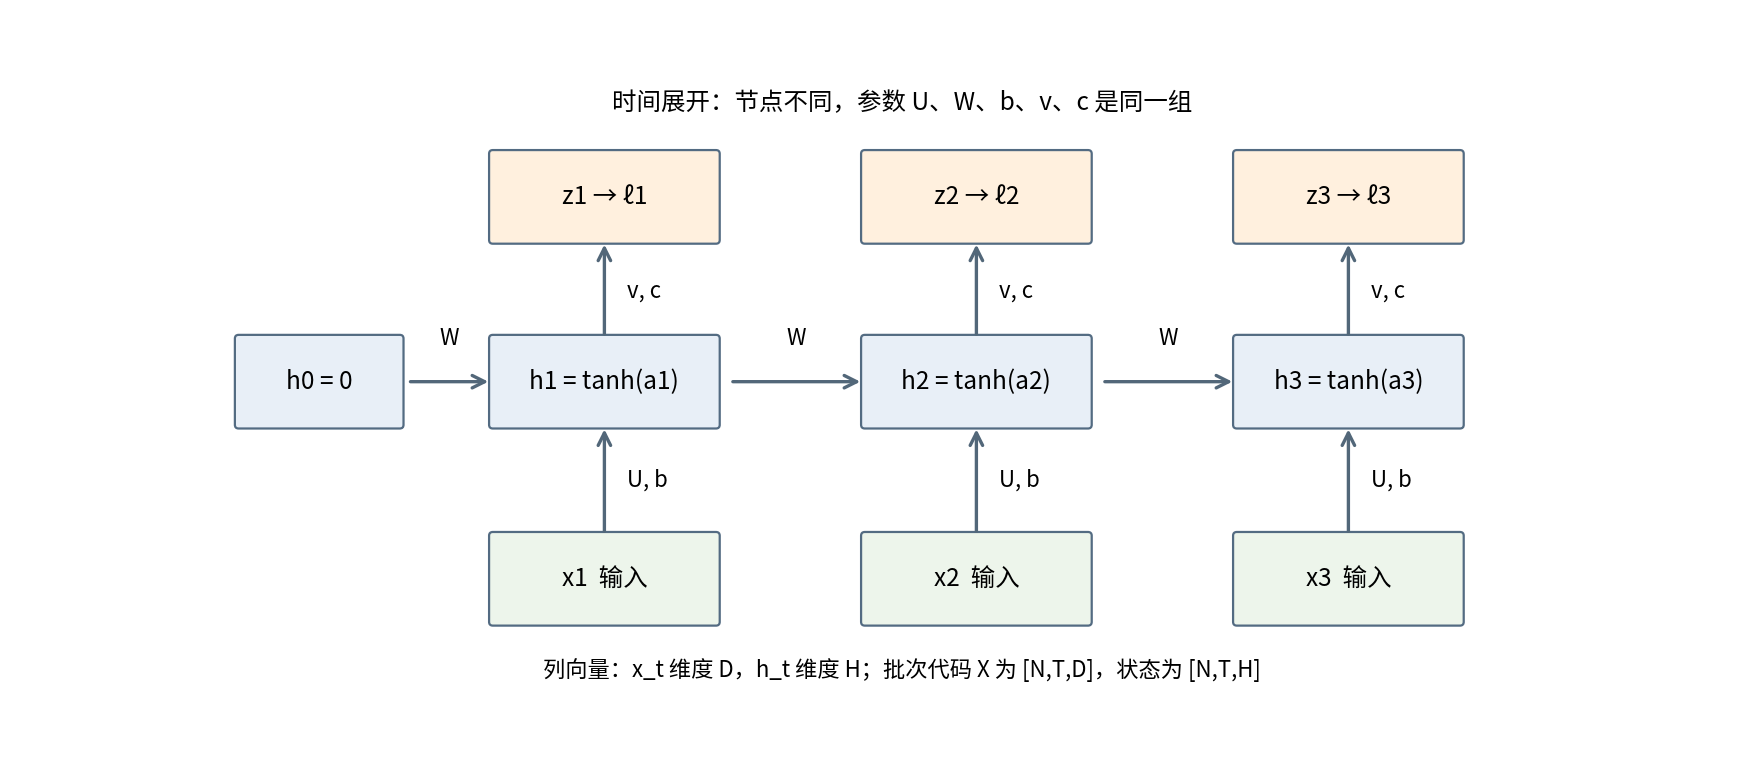

02_hand_forward.png


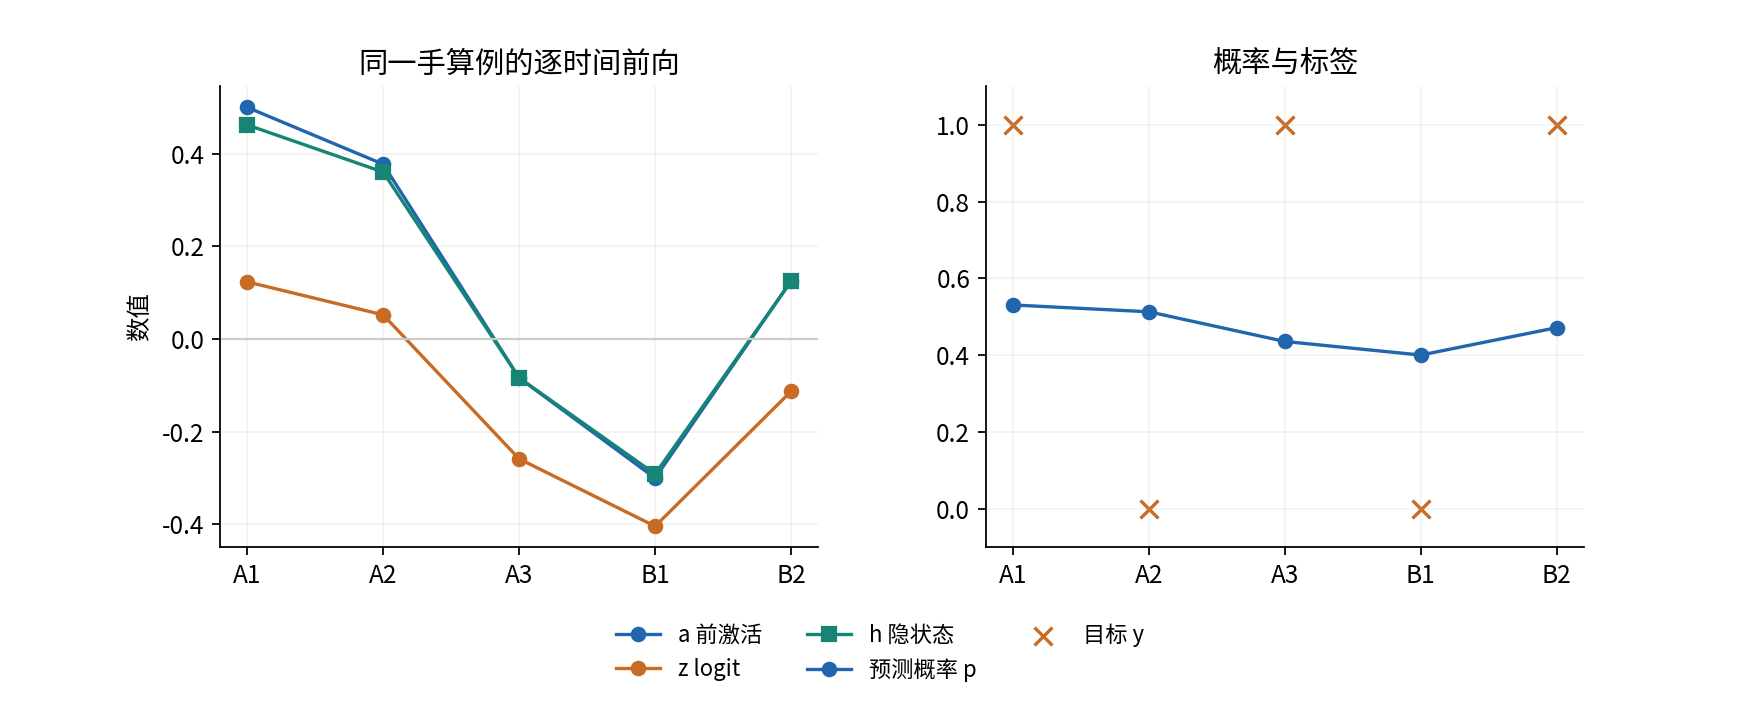

03_local_backward.png


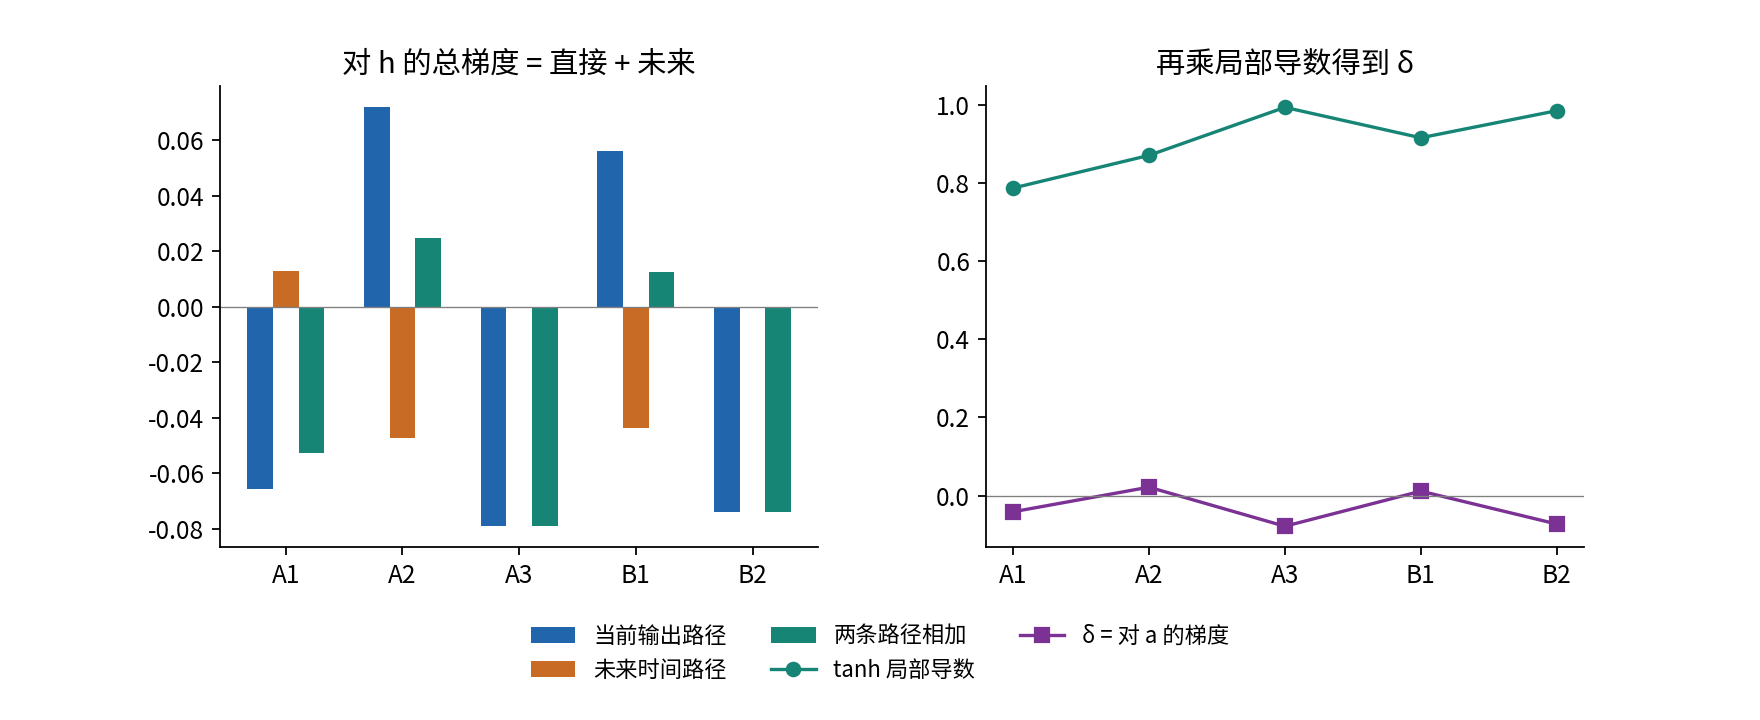

04_shared_gradients.png


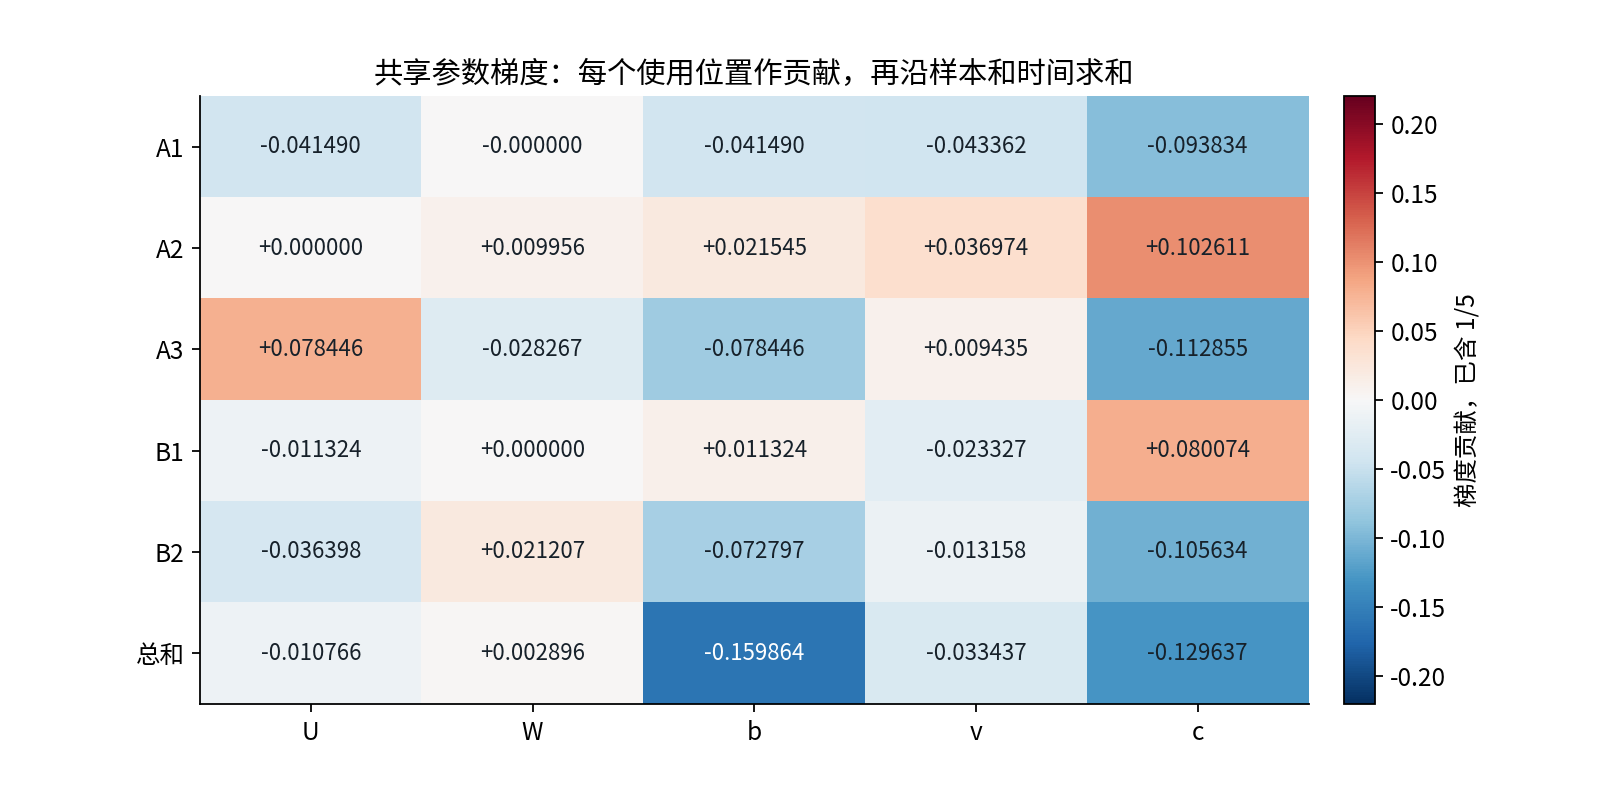

05_update.png


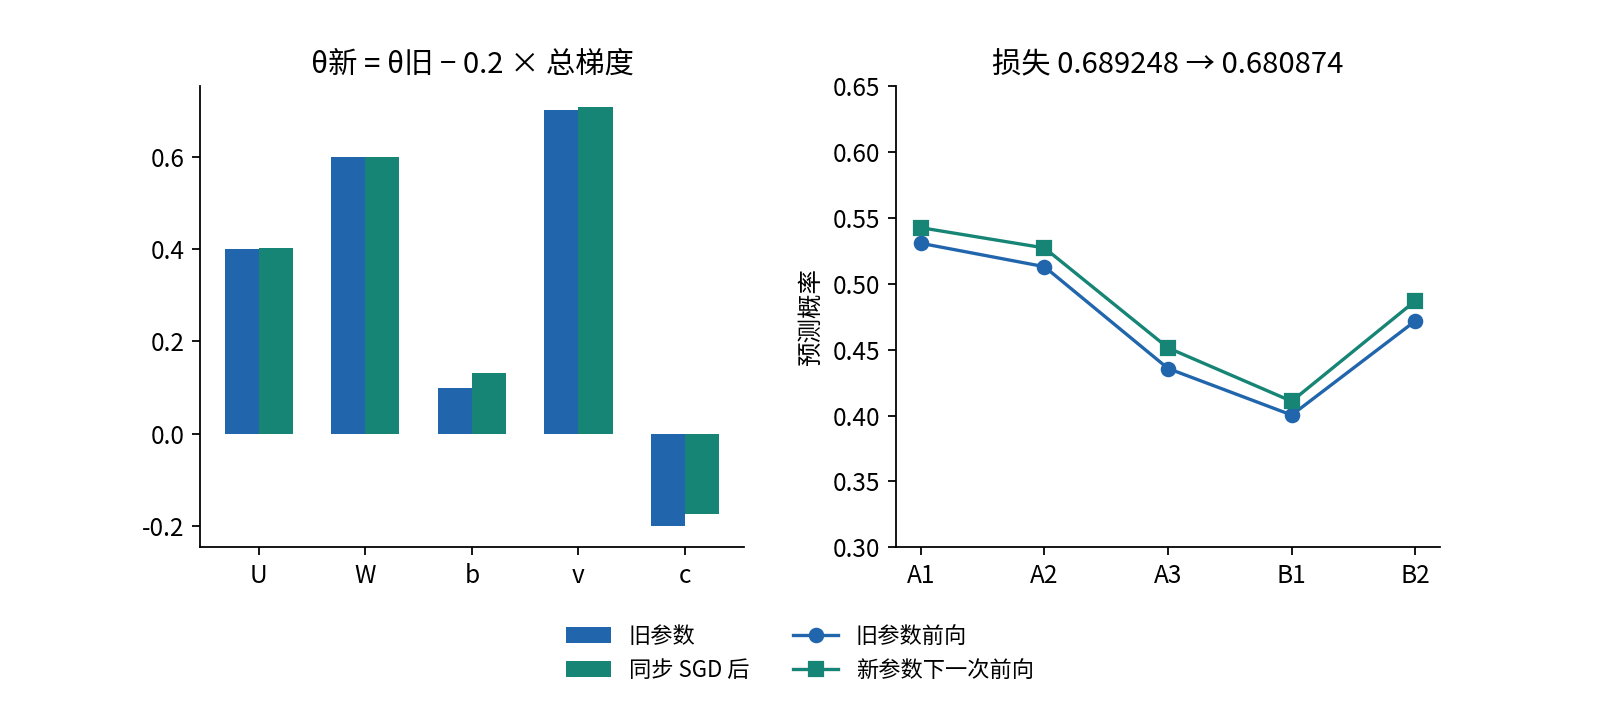

06_jacobian.png


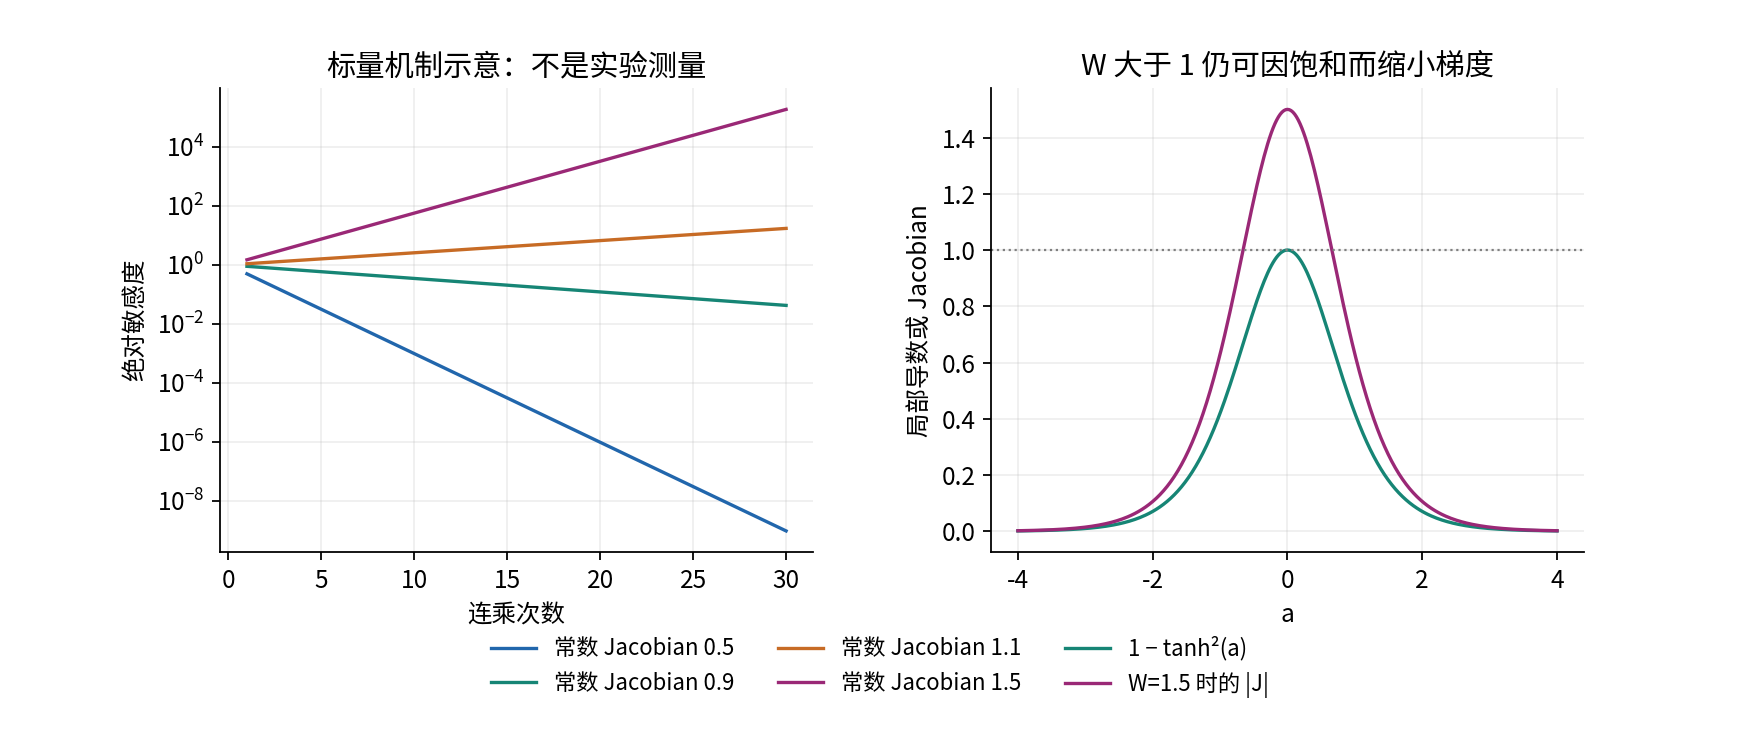

07_detach.png


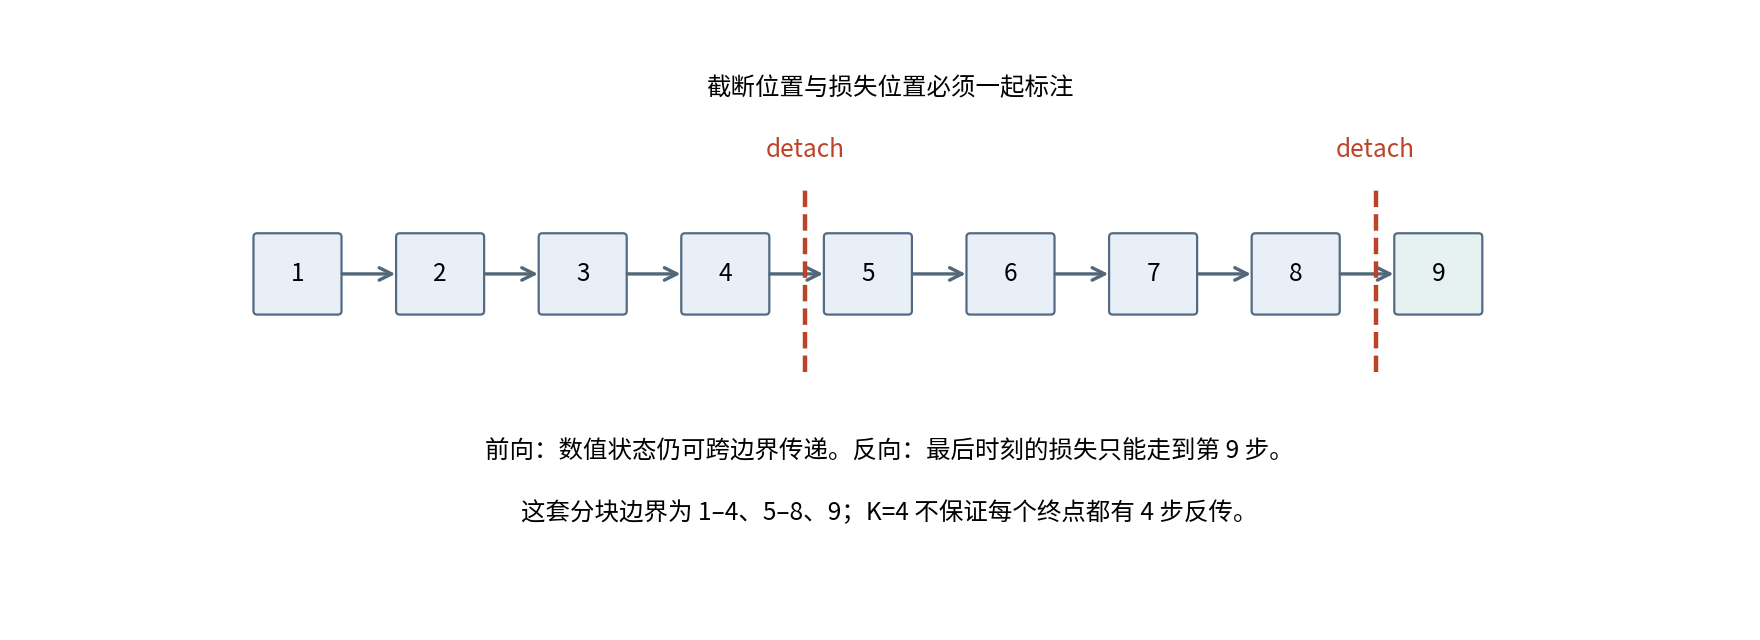

08_data.png


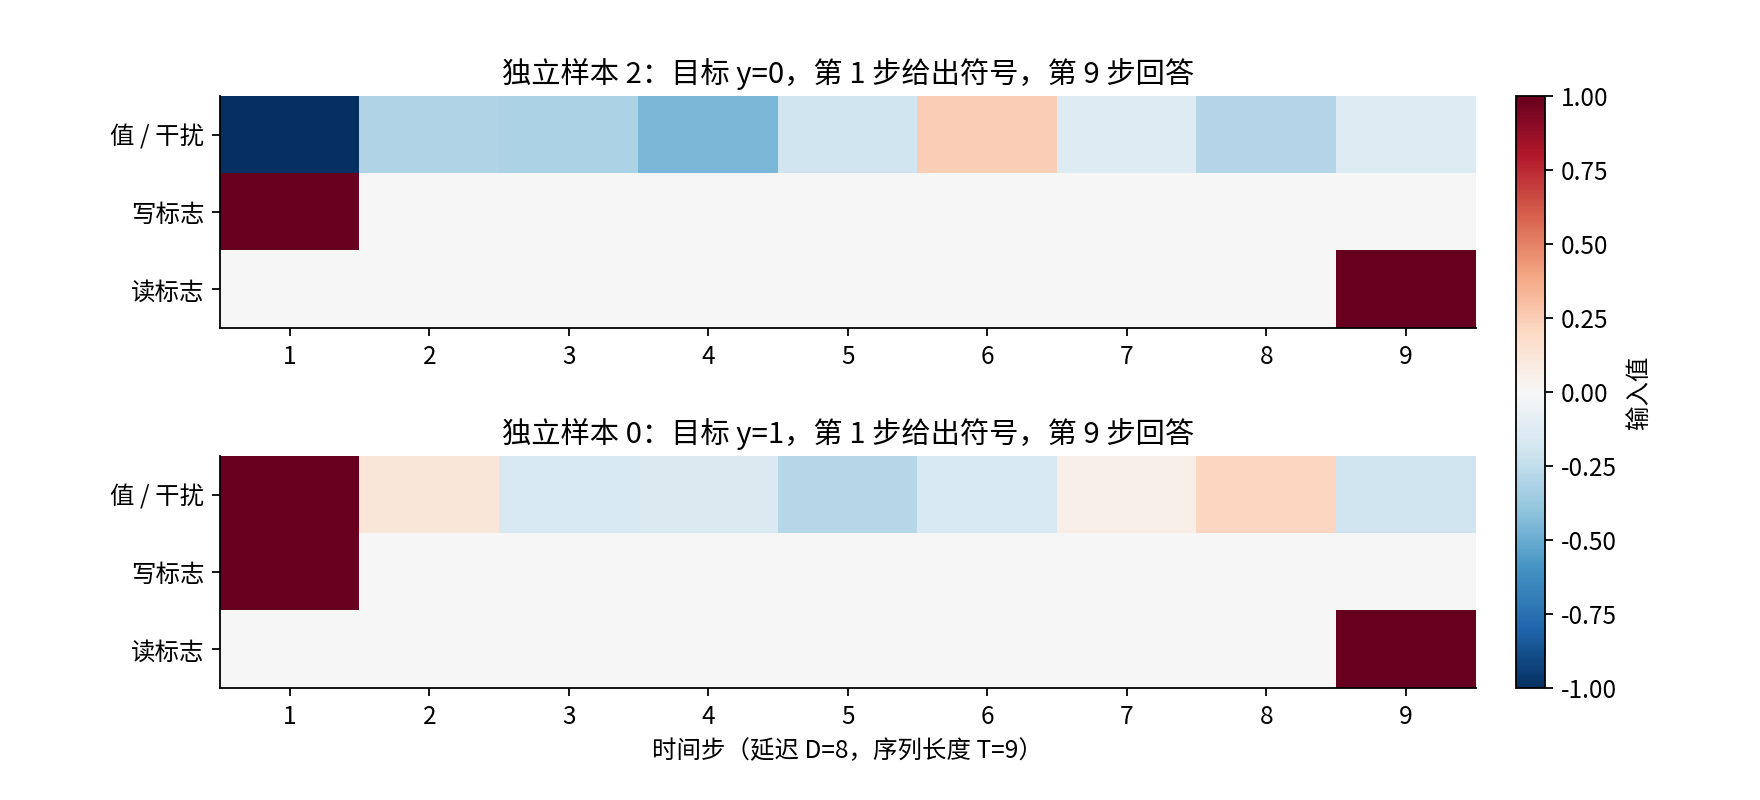

09_training.png


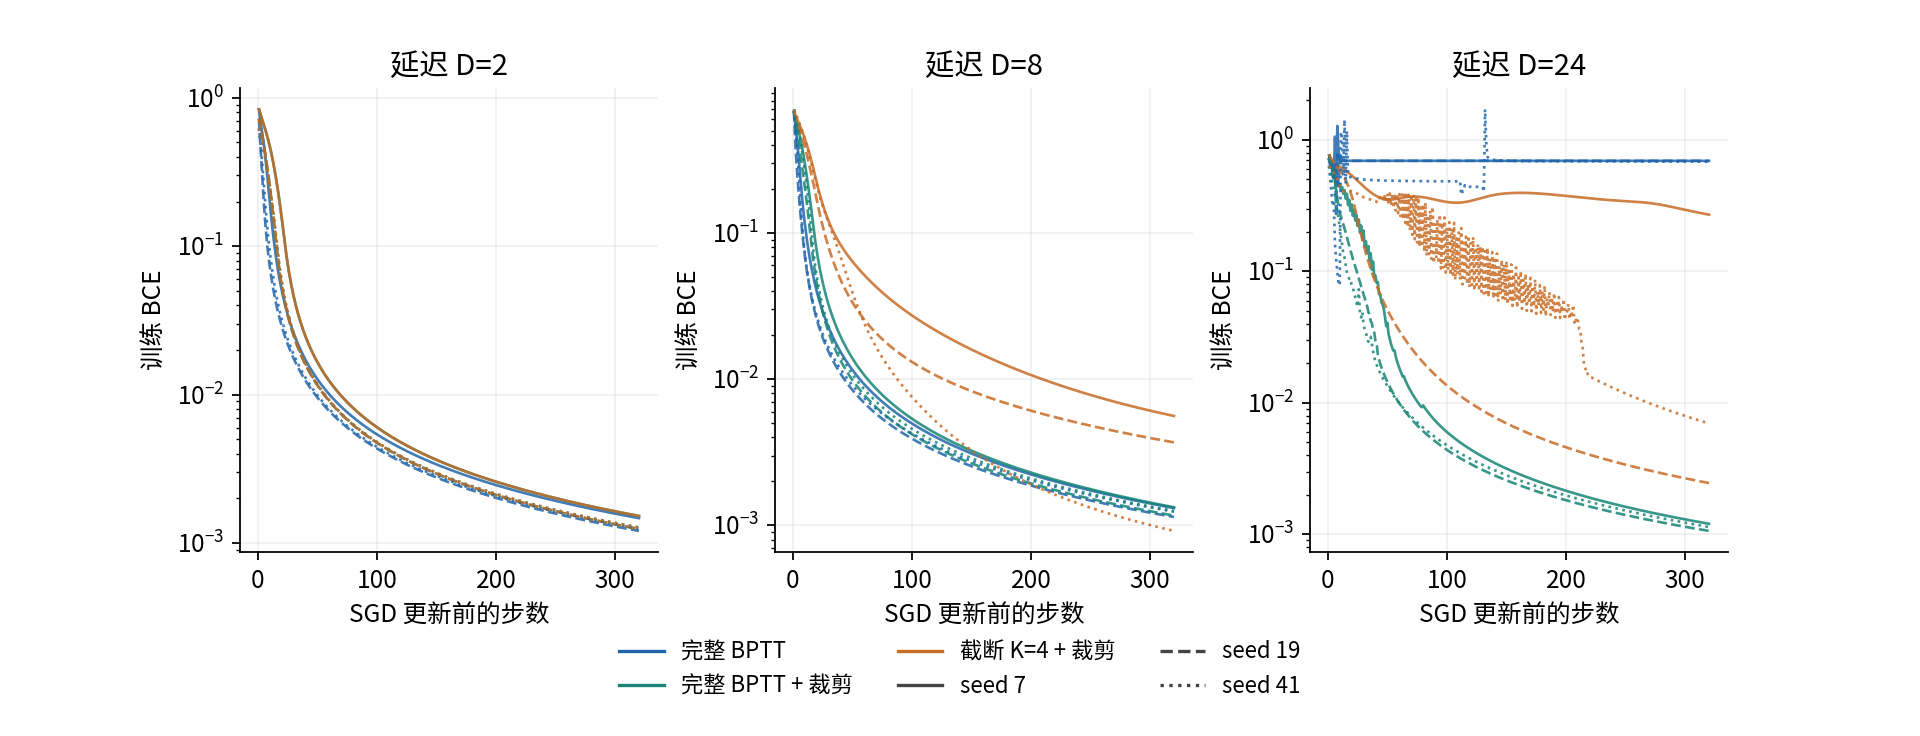

10_test_results.png


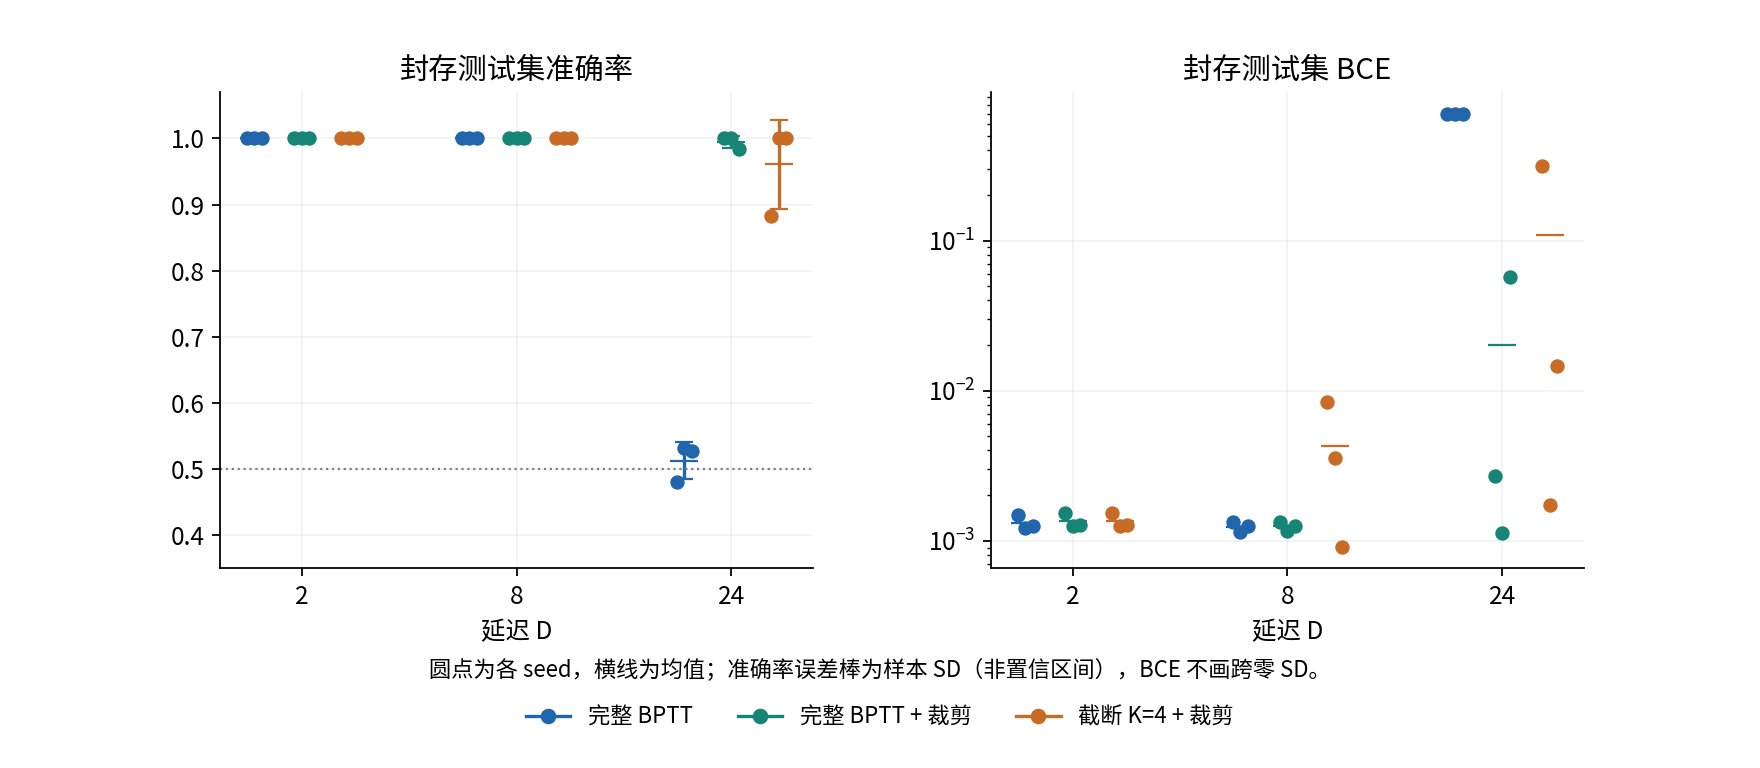

11_clipping.png


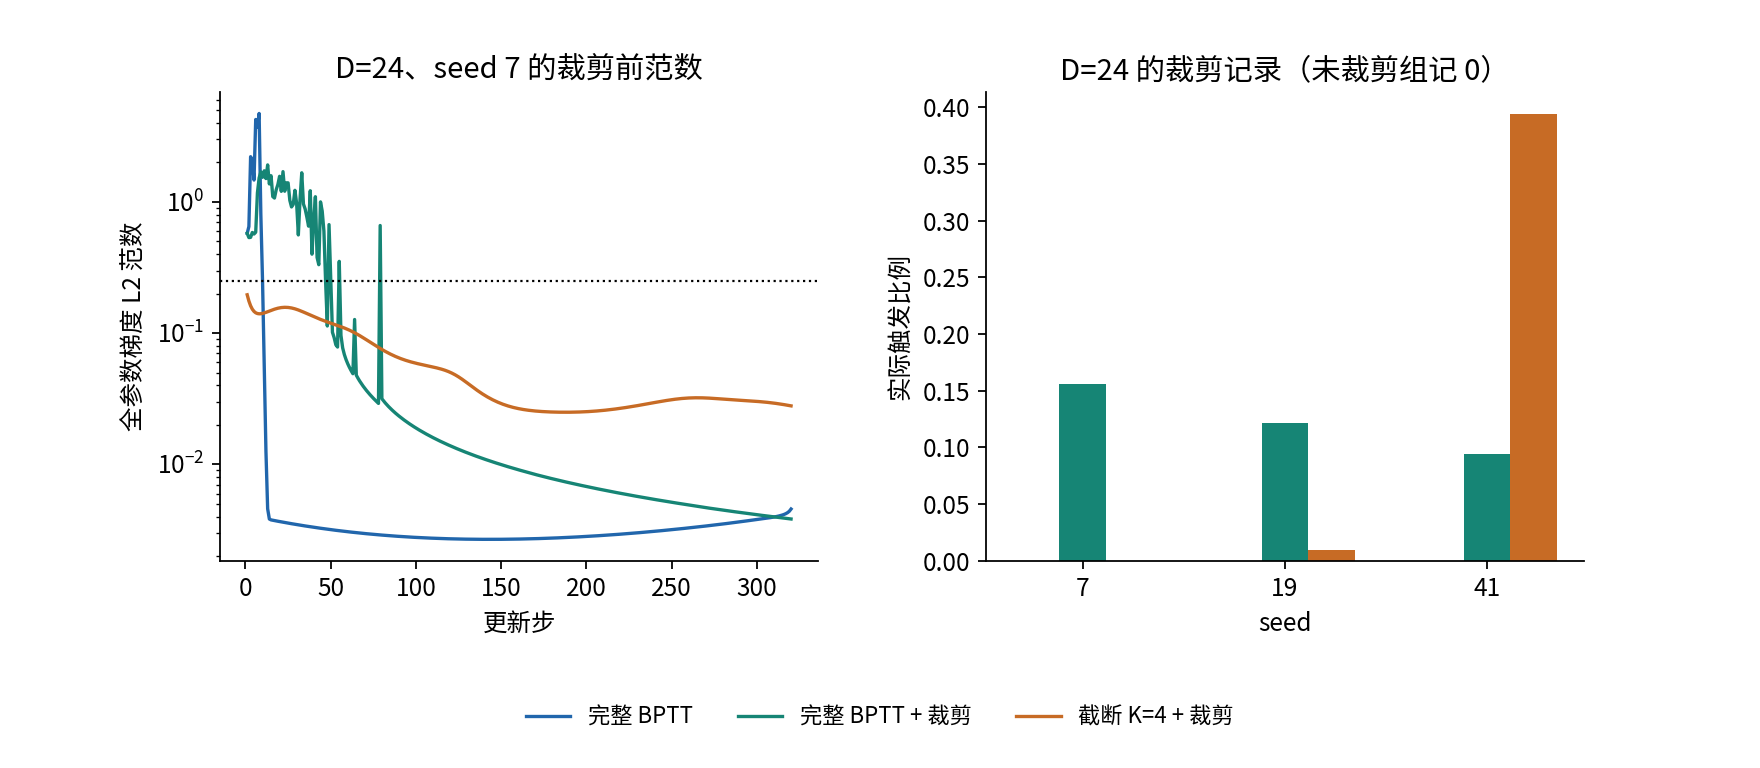

12_input_gradients.png


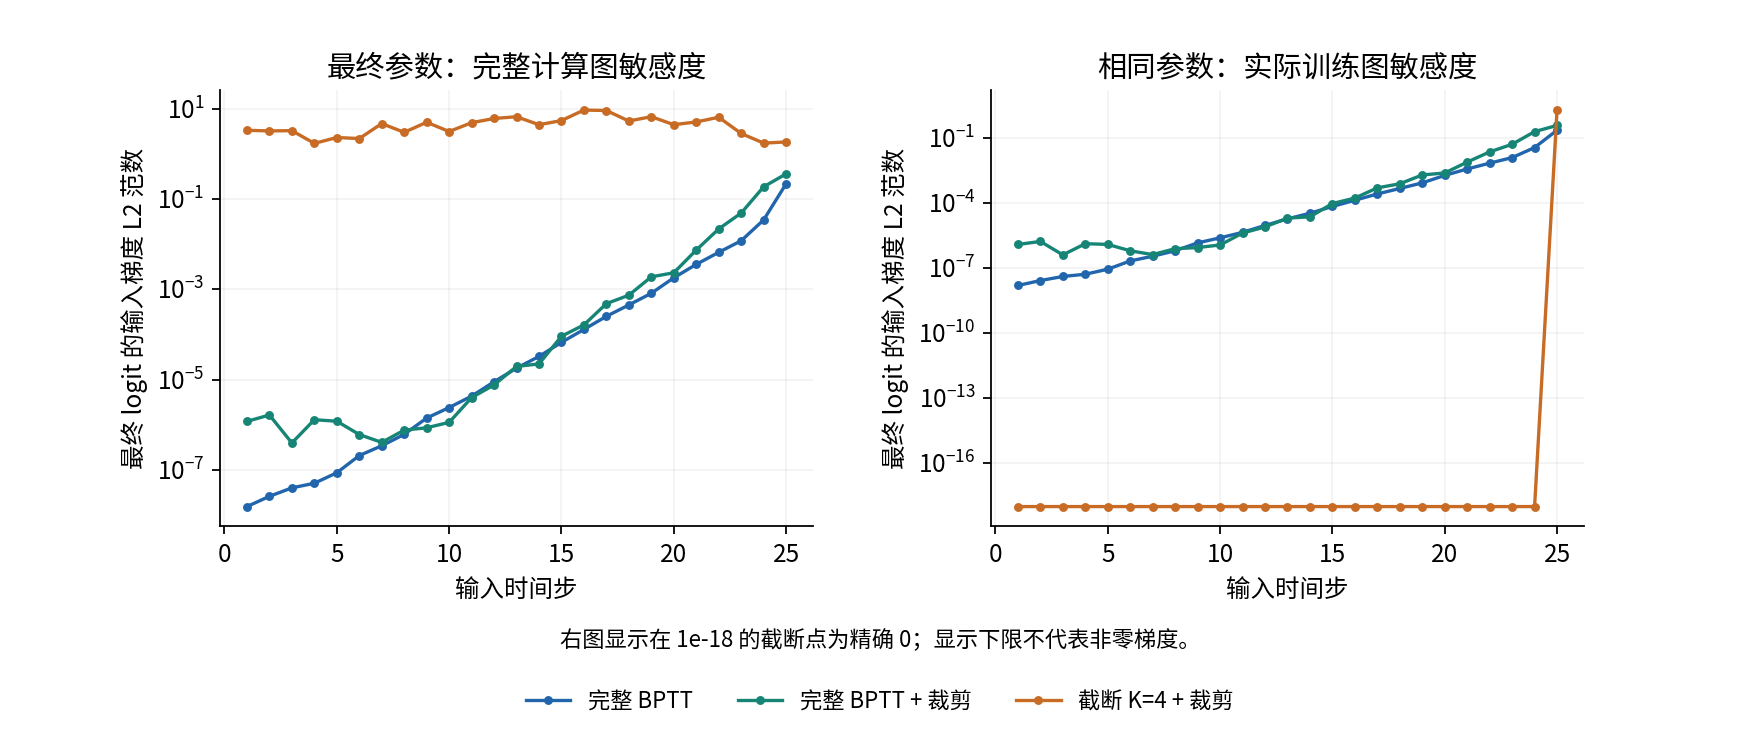

13_counterfactual.png


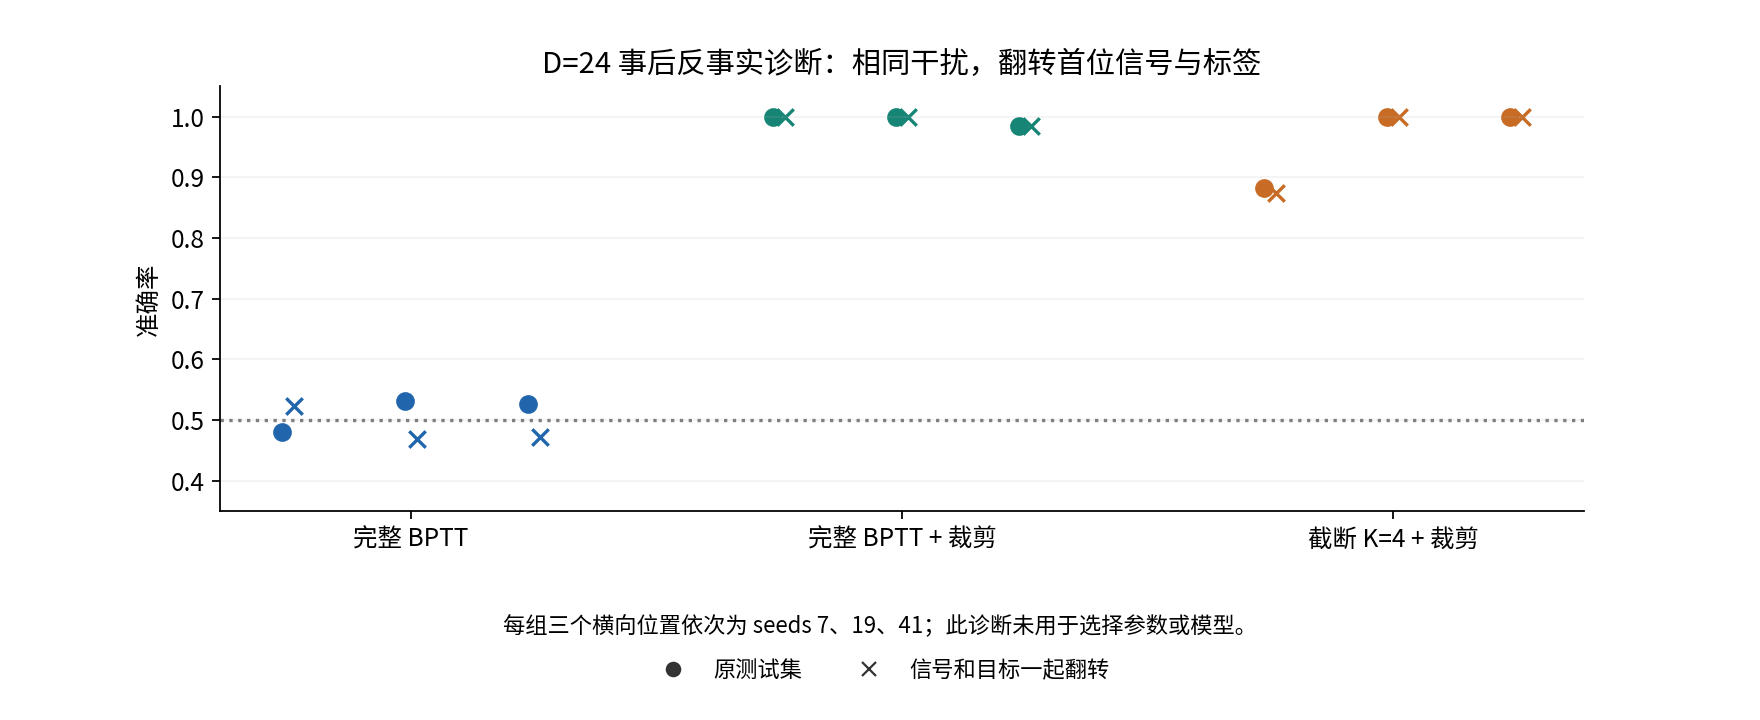

In [9]:
from make_figures import main as make_figures
figure_dir=Path(tempfile.mkdtemp(prefix='dl050-notebook-figures-'))
make_figures(figure_dir)
from io import BytesIO
from IPython.display import Image, display
for path in sorted(figure_dir.glob('*.png')):
    print(path.name)
    buffer=BytesIO(path.read_bytes())
    display(Image(data=buffer.getvalue(),format='png'))

## 9 核对事后反事实诊断
翻转首位信号和标签，保留所有干扰。它在预定训练完成后追加，不用于超参或模型选择；擦除首位信号的结果也完整保留。

In [10]:
from experiment import evaluate
weights=np.load(ROOT/'outputs/trained_parameters.npz',allow_pickle=False)
data=np.load(ROOT/'data/delayed_sign.npz',allow_pickle=False)
archived_cf=json.loads((ROOT/'outputs/counterfactual.json').read_text())
for run in reproduction['runs']:
    rid=run['id'];delay=run['delay']
    pp=params_from_numpy({k:weights[rid+'_'+k] for k in NAMES})
    x0=data[f'd{delay}_test_x'].copy();y0=data[f'd{delay}_test_y'].copy()
    flipped=x0.copy();flipped[:,0,0]*=-1
    erased=x0.copy();erased[:,0,0]=0.
    measured={'id':rid,'flipped_signal_and_label':evaluate(pp,tensor(flipped),tensor(1-y0)),'erased_first_signal':evaluate(pp,tensor(erased),tensor(y0))}
    expected=next(v for v in archived_cf['runs'] if v['id']==rid)
    if measured!=expected:raise RuntimeError('反事实诊断与记录不一致 '+rid)
    print(rid, measured['flipped_signal_and_label']['accuracy'],measured['erased_first_signal']['accuracy'])
print('以上只是本 toy 分布的诊断，不构成自然语言或长文泛化结论。')

d2_s7_full 1.0 0.4921875
d2_s7_full_clip 1.0 0.4921875
d2_s7_tbptt4_clip 1.0 0.4921875
d2_s19_full 1.0 0.5546875
d2_s19_full_clip 1.0 0.55078125
d2_s19_tbptt4_clip 1.0 0.55078125
d2_s41_full 1.0 0.48828125
d2_s41_full_clip 1.0 0.49609375
d2_s41_tbptt4_clip 1.0 0.49609375
d8_s7_full 1.0 0.4609375
d8_s7_full_clip 1.0 0.46484375
d8_s7_tbptt4_clip 1.0 0.4921875
d8_s19_full 1.0 0.5
d8_s19_full_clip 1.0 0.5
d8_s19_tbptt4_clip 1.0 0.51171875
d8_s41_full 1.0 0.50390625
d8_s41_full_clip 1.0 0.49609375
d8_s41_tbptt4_clip 1.0 0.5
d24_s7_full 0.5234375 0.48046875
d24_s7_full_clip 1.0 0.47265625
d24_s7_tbptt4_clip 0.875 0.49609375
d24_s19_full 0.46875 0.53125
d24_s19_full_clip 1.0 0.5
d24_s19_tbptt4_clip 1.0 0.51171875
d24_s41_full 0.47265625 0.52734375
d24_s41_full_clip 0.984375 0.5
d24_s41_tbptt4_clip 1.0 0.48828125
以上只是本 toy 分布的诊断，不构成自然语言或长文泛化结论。


## 10 复验边界
已执行：实际新 IPython 内核内的完整数值链、独立检查、27 组训练、全部图像和反事实计算。未执行：浏览器 Jupyter 界面、外部 socket、GPU、混合精度、任意长序列。独立审阅与作者自检不同；科研结论以公开数据和协议为依据，不能以检查数量代替证据质量。

原始技术来源与版本见 sources.md；详细推导和完整答案见 lecture.md、answers.md。